In [1]:
!nvidia-smi

Mon May  4 20:22:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!git clone https://github.com/VuTrinhNguyenHoang/bidirectional-table-text-alignment.git

Cloning into 'bidirectional-table-text-alignment'...
remote: Enumerating objects: 207, done.
remote: Counting objects: 100% (207/207), done.
remote: Compressing objects: 100% (128/128), done.
remote: Total 207 (delta 98), reused 165 (delta 59), pack-reused 0 (from 0)
Receiving objects: 100% (207/207), 63.12 KiB | 1.58 MiB/s, done.
Resolving deltas: 100% (98/98), done.


In [3]:
%cd bidirectional-table-text-alignment

/kaggle/working/bidirectional-table-text-alignment


In [4]:
!pip -q install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 7.3 MB/s eta 0:00:00


In [5]:
!mkdir -p outputs/data/processed
!cp -a /kaggle/input/models/trnhvu2/bitt/pytorch/default/1/data/processed/. outputs/data/processed/

In [6]:
from pathlib import Path
import os, sys, json, shutil, subprocess
import pandas as pd
import matplotlib.pyplot as plt

MODE = "small"
CONFIG = "configs/main.yaml"
TOP_K = 3
THRESHOLD_STEP = 0.01

MODEL_ROOT = Path("/kaggle/input/models/trnhvu/bitt/pytorch/default/1")
DATA_ROOT = Path("/kaggle/input/models/trnhvu2/bitt/pytorch/default/1/data/processed")

GENERATOR_SLOT = "full"
SELECTOR_SLOT = "medium"

GEN_SLOT_PATH = Path(f"outputs/checkpoints/{GENERATOR_SLOT}/final")
SEL_SLOT_PATH = Path(f"outputs/checkpoints/cell_selector/{SELECTOR_SLOT}/final")
GRID_DIR = Path(f"outputs/metrics/{MODE}/grid_eval")
GRID_DIR.mkdir(parents=True, exist_ok=True)

GENERATORS = {
    "t5-small": MODEL_ROOT / "t5-small",
    "flan-t5-small": MODEL_ROOT / "flan-t5-small",
    "t5-v1_1-small": MODEL_ROOT / "t5-v1_1-small",
}

SELECTORS = {
    "distilbert-base-uncased": MODEL_ROOT / "distillbert-base-uncased",
    "MiniLM-L12-H384-uncased": MODEL_ROOT / "MiniLM-L12-H384-uncased",
    "electra-small-discriminator": MODEL_ROOT / "electra-small-discriminator",
}

In [7]:
def checkpoint_source(path):
    path = Path(path)
    return path / "final" if (path / "final").exists() else path

def copy_checkpoint(src, dst):
    src = checkpoint_source(src)
    assert (src / "config.json").exists(), f"Missing checkpoint: {src}"
    shutil.rmtree(dst, ignore_errors=True)
    dst.parent.mkdir(parents=True, exist_ok=True)
    shutil.copytree(src, dst)

def run_script(args):
    env = os.environ.copy()
    env["PYTHONPATH"] = "."
    subprocess.run([sys.executable, *args], check=True, env=env)

def threshold_tag(th):
    return f"threshold{th:.4f}".replace(".", "p")

In [8]:
selector_thresholds = {}

for selector_name, selector_src in SELECTORS.items():
    copy_checkpoint(selector_src, SEL_SLOT_PATH)

    run_script([
        "scripts/tune_cell_selector_threshold.py",
        "--mode", MODE,
        "--selector-mode", SELECTOR_SLOT,
        "--config", CONFIG,
        "--top_k", str(TOP_K),
        "--split", "valid",
        "--threshold_step", str(THRESHOLD_STEP),
    ])

    tuning_path = Path(f"outputs/metrics/{MODE}/cell_selector_threshold_tuning_valid_top{TOP_K}.json")
    tuning = json.loads(tuning_path.read_text())
    selector_thresholds[selector_name] = tuning["best_threshold"]

    shutil.copy2(tuning_path, GRID_DIR / f"threshold__{selector_name}.json")

Sweeping thresholds: 100%|██████████| 101/101 [00:03<00:00, 25.37it/s]


{
  "mode": "small",
  "split": "valid",
  "selector_mode": "medium",
  "top_k": 3,
  "selection_strategy": "threshold_with_top_k_fallback",
  "best_threshold": 0.74,
  "best_metrics": {
    "cell_precision": 0.8235,
    "cell_recall": 0.7486892732790559,
    "cell_f1": 0.7536442248913686,
    "cell_exact_match": 0.334,
    "threshold": 0.74,
    "top_k": 3,
    "fallback_rate": 0.569,
    "empty_threshold_rate": 0.002,
    "overflow_threshold_rate": 0.567,
    "avg_selected_count": 2.674,
    "candidate_filter_rate": 0.032,
    "avg_table_cells": 236.605,
    "avg_candidate_cells": 159.597
  },
  "results": [
    {
      "cell_precision": 0.7296666666666666,
      "cell_recall": 0.7571226066123892,
      "cell_f1": 0.6990489867961305,
      "cell_exact_match": 0.173,
      "threshold": 0.0,
      "top_k": 3,
      "fallback_rate": 1.0,
      "empty_threshold_rate": 0.0,
      "overflow_threshold_rate": 1.0,
      "avg_selected_count": 3.0,
      "candidate_filter_rate": 0.032,
      "

Sweeping thresholds: 100%|██████████| 101/101 [00:04<00:00, 23.83it/s]


{
  "mode": "small",
  "split": "valid",
  "selector_mode": "medium",
  "top_k": 3,
  "selection_strategy": "threshold_with_top_k_fallback",
  "best_threshold": 0.84,
  "best_metrics": {
    "cell_precision": 0.676,
    "cell_recall": 0.4097554304029304,
    "cell_f1": 0.47292453931578854,
    "cell_exact_match": 0.099,
    "threshold": 0.84,
    "top_k": 3,
    "fallback_rate": 0.34,
    "empty_threshold_rate": 0.168,
    "overflow_threshold_rate": 0.172,
    "avg_selected_count": 2.12,
    "candidate_filter_rate": 0.032,
    "avg_table_cells": 236.605,
    "avg_candidate_cells": 159.597
  },
  "results": [
    {
      "cell_precision": 0.4503333333333333,
      "cell_recall": 0.45294991092241094,
      "cell_f1": 0.4238691956256622,
      "cell_exact_match": 0.017,
      "threshold": 0.0,
      "top_k": 3,
      "fallback_rate": 1.0,
      "empty_threshold_rate": 0.0,
      "overflow_threshold_rate": 1.0,
      "avg_selected_count": 3.0,
      "candidate_filter_rate": 0.032,
      "a

Sweeping thresholds: 100%|██████████| 101/101 [00:04<00:00, 24.19it/s]


{
  "mode": "small",
  "split": "valid",
  "selector_mode": "medium",
  "top_k": 3,
  "selection_strategy": "threshold_with_top_k_fallback",
  "best_threshold": 0.78,
  "best_metrics": {
    "cell_precision": 0.8195,
    "cell_recall": 0.7386720502243328,
    "cell_f1": 0.7465207237707198,
    "cell_exact_match": 0.322,
    "threshold": 0.78,
    "top_k": 3,
    "fallback_rate": 0.554,
    "empty_threshold_rate": 0.003,
    "overflow_threshold_rate": 0.551,
    "avg_selected_count": 2.663,
    "candidate_filter_rate": 0.032,
    "avg_table_cells": 236.605,
    "avg_candidate_cells": 159.597
  },
  "results": [
    {
      "cell_precision": 0.7256666666666667,
      "cell_recall": 0.7516720502243328,
      "cell_f1": 0.6943683428183389,
      "cell_exact_match": 0.165,
      "threshold": 0.0,
      "top_k": 3,
      "fallback_rate": 1.0,
      "empty_threshold_rate": 0.0,
      "overflow_threshold_rate": 1.0,
      "avg_selected_count": 3.0,
      "candidate_filter_rate": 0.032,
      "

In [9]:
rows = []

for selector_name, selector_src in SELECTORS.items():
    copy_checkpoint(selector_src, SEL_SLOT_PATH)
    threshold = selector_thresholds[selector_name]

    for generator_name, generator_src in GENERATORS.items():
        copy_checkpoint(generator_src, GEN_SLOT_PATH)

        run_script([
            "scripts/evaluation_e2e.py",
            "--mode", MODE,
            "--generator-mode", GENERATOR_SLOT,
            "--selector-mode", SELECTOR_SLOT,
            "--config", CONFIG,
            "--top_k", str(TOP_K),
            "--threshold", str(threshold),
        ])

        tag = f"{threshold_tag(threshold)}_top{TOP_K}"
        metric_path = Path(f"outputs/metrics/{MODE}/e2e_metrics_{tag}.json")
        metrics = json.loads(metric_path.read_text())

        row = {
            "selector": selector_name,
            "generator": generator_name,
            "threshold": threshold,
            "cell_f1": metrics["cell_selection"]["cell_f1"],
            "bleu": metrics["generation"]["bleu"]["score"],
            "rougeL": metrics["generation"]["rouge"]["rougeL"],
            "semantic_cosine": metrics["consistency"]["semantic"]["cosine_mean"],
            "faithful_number_rate": metrics["faithfulness"]["faithful_number_rate"],
        }
        rows.append(row)

        shutil.copy2(metric_path, GRID_DIR / f"e2e__{selector_name}__{generator_name}.json")

df = pd.DataFrame(rows)
df.to_csv(GRID_DIR / "grid_results.csv", index=False)
df.sort_values("bleu", ascending=False)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1675.50it/s, Materializing param=pooler.dense.weight]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Running E2E: 100%|██████████| 1000/1000 [17:11<00:00,  1.03s/it]


{
  "mode": "small",
  "generator_mode": "full",
  "selector_mode": "medium",
  "top_k": 3,
  "threshold": 0.74,
  "selection_strategy": "threshold_with_top_k_fallback",
  "cell_selection": {
    "cell_precision": 0.8235,
    "cell_recall": 0.7486892732790559,
    "cell_f1": 0.7536442248913686,
    "cell_exact_match": 0.334
  },
  "consistency": {
    "lexical": {
      "bleu": {
        "score": 28.20072987960116,
        "counts": [
          9664,
          5417,
          3436,
          2262
        ],
        "totals": [
          14436,
          13436,
          12436,
          11436
        ],
        "precisions": [
          66.94375173178166,
          40.31705864840726,
          27.62946284979093,
          19.779643231899264
        ],
        "bp": 0.8092130961507831,
        "sys_len": 14436,
        "ref_len": 17492
      },
      "rouge": {
        "rouge1": 0.6301366520039786,
        "rouge2": 0.4082705486765197,
        "rougeL": 0.5417008859831822,
        "roug

Loading weights: 100%|██████████| 190/190 [00:00<00:00, 1602.96it/s, Materializing param=shared.weight]
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1633.41it/s, Materializing param=pooler.dense.weight]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Running E2E: 100%|██████████| 1000/1000 [18:53<00:00,  1.13s/it]


{
  "mode": "small",
  "generator_mode": "full",
  "selector_mode": "medium",
  "top_k": 3,
  "threshold": 0.74,
  "selection_strategy": "threshold_with_top_k_fallback",
  "cell_selection": {
    "cell_precision": 0.8235,
    "cell_recall": 0.7486892732790559,
    "cell_f1": 0.7536442248913686,
    "cell_exact_match": 0.334
  },
  "consistency": {
    "lexical": {
      "bleu": {
        "score": 28.03702596786167,
        "counts": [
          9671,
          5403,
          3407,
          2223
        ],
        "totals": [
          14638,
          13638,
          12638,
          11638
        ],
        "precisions": [
          66.06776882087716,
          39.617245930488345,
          26.9583794904257,
          19.101220140917682
        ],
        "bp": 0.8228577053940759,
        "sys_len": 14638,
        "ref_len": 17492
      },
      "rouge": {
        "rouge1": 0.6265621046515152,
        "rouge2": 0.4069294012867728,
        "rougeL": 0.5395109505547766,
        "roug

Loading weights: 100%|██████████| 192/192 [00:00<00:00, 2014.15it/s, Materializing param=shared.weight]
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1698.31it/s, Materializing param=pooler.dense.weight]
B

...

Loading weights: 100%|██████████| 190/190 [00:00<00:00, 1562.78it/s, Materializing param=shared.weight]
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1644.24it/s, Materializing param=pooler.dense.weight]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Running E2E: 100%|██████████| 1000/1000 [10:48<00:00,  1.54it/s]


{
  "mode": "small",
  "generator_mode": "full",
  "selector_mode": "medium",
  "top_k": 3,
  "threshold": 0.78,
  "selection_strategy": "threshold_with_top_k_fallback",
  "cell_selection": {
    "cell_precision": 0.8195,
    "cell_recall": 0.7386720502243328,
    "cell_f1": 0.7465207237707198,
    "cell_exact_match": 0.322
  },
  "consistency": {
    "lexical": {
      "bleu": {
        "score": 27.574424959146793,
        "counts": [
          9584,
          5301,
          3348,
          2183
        ],
        "totals": [
          14505,
          13505,
          12505,
          11505
        ],
        "precisions": [
          66.07376766632196,
          39.252128841169935,
          26.773290683726508,
          18.974358974358974
        ],
        "bp": 0.8138908686187547,
        "sys_len": 14505,
        "ref_len": 17492
      },
      "rouge": {
        "rouge1": 0.6231897758949481,
        "rouge2": 0.3984899454763237,
        "rougeL": 0.5354233395966221,
        "r

Loading weights: 100%|██████████| 192/192 [00:00<00:00, 1704.01it/s, Materializing param=shared.weight]
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1666.37it/s, Materializing param=pooler.dense.weight]
B

{
  "mode": "small",
  "generator_mode": "full",
  "selector_mode": "medium",
  "top_k": 3,
  "threshold": 0.78,
  "selection_strategy": "threshold_with_top_k_fallback",
  "cell_selection": {
    "cell_precision": 0.8195,
    "cell_recall": 0.7386720502243328,
    "cell_f1": 0.7465207237707198,
    "cell_exact_match": 0.322
  },
  "consistency": {
    "lexical": {
      "bleu": {
        "score": 27.057991814391528,
        "counts": [
          9462,
          5208,
          3280,
          2141
        ],
        "totals": [
          14298,
          13298,
          12298,
          11298
        ],
        "precisions": [
          66.17708770457406,
          39.16378402767334,
          26.67100341518946,
          18.950256682598692
        ],
        "bp": 0.7998045557951355,
        "sys_len": 14298,
        "ref_len": 17492
      },
      "rouge": {
        "rouge1": 0.617796461300856,
        "rouge2": 0.39269215879189356,
        "rougeL": 0.5295072927092082,
        "rou

,selector,generator,threshold,cell_f1,bleu,rougeL,semantic_cosine,faithful_number_rate
6,electra-small-discriminator,t5-small,0.78,0.746521,28.344275,0.539749,0.815709,0.850
0,distilbert-base-uncased,t5-small,0.74,0.753644,28.200730,0.541701,0.816037,0.850
1,distilbert-base-uncased,flan-t5-small,0.74,0.753644,28.037026,0.539511,0.816726,0.830
7,electra-small-discriminator,flan-t5-small,0.78,0.746521,27.574425,0.535423,0.817123,0.830
8,electra-small-discriminator,t5-v1_1-small,0.78,0.746521,27.057992,0.529507,0.811247,0.828
2,distilbert-base-uncased,t5-v1_1-small,0.74,0.753644,26.875895,0.529736,0.809048,0.823
3,MiniLM-L12-H384-uncased,t5-small,0.84,0.472925,17.925022,0.422146,0.665664,0.812
4,MiniLM-L12-H384-uncased,flan-t5-small,0.84,0.472925,17.571021,0.419010,0.666052,0.800
5,MiniLM-L12-H384-uncased,t5-v1_1-small,0.84,0.472925,17.369026,0.414415,0.662813,0.786


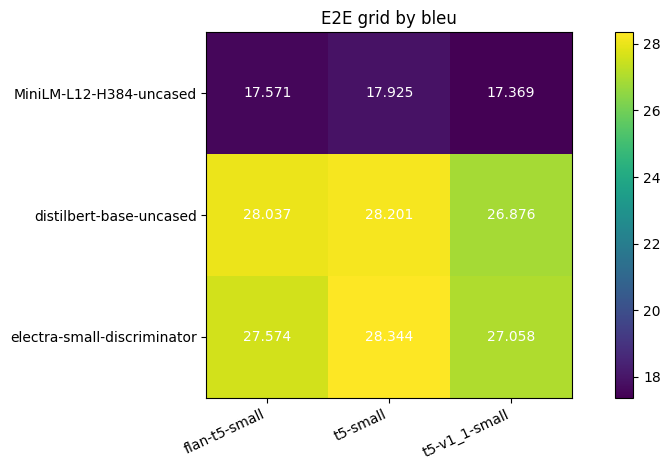

In [10]:
PRIMARY_METRIC = "bleu"  # hoặc "bleu", "semantic_cosine"

pivot = df.pivot(index="selector", columns="generator", values=PRIMARY_METRIC)

fig, ax = plt.subplots(figsize=(9, 4.8))
im = ax.imshow(pivot.values, cmap="viridis")

ax.set_xticks(range(len(pivot.columns)), labels=pivot.columns, rotation=25, ha="right")
ax.set_yticks(range(len(pivot.index)), labels=pivot.index)
ax.set_title(f"E2E grid by {PRIMARY_METRIC}")

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f"{pivot.iloc[i, j]:.3f}", ha="center", va="center", color="white")

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(GRID_DIR / f"grid_{PRIMARY_METRIC}.png", dpi=200)
plt.show()